I need to have a envinronment that given an action returns the state and reward.

In [2]:
import numpy as np
from itertools import product
import scipy.stats as stats

# Environment

In [3]:
class car_rental:
    def __init__(self, reward_per_car, cost_to_move_car, max_moving, locations: int, rental_requests, rental_returns, max_storage_of_locations, debug=False):

        self.reward_per_car = reward_per_car
        self.cost_to_move_car = cost_to_move_car
        self.max_moving = max_moving
        self.locations = locations
        self.rental_requests = rental_requests
        self.rental_returns = rental_returns
        self.max_storage_of_locations = max_storage_of_locations

        if len(rental_requests) != locations or len(rental_returns) != locations:
            raise ValueError('The length of rental_requests and rental_returns should be equal to the number of locations')

        # Initialize the number of cars at each location to be max_storage_of_locations
        self.state = np.array([max_storage_of_locations for i in range(locations)])

        self.debug = debug
        self.logs = []

        # Precompute Poisson probabilities for rental requests and returns
        self.rental_request_probs = [
            {i: stats.poisson.pmf(i, self.rental_requests[location]) for i in range(self.max_storage_of_locations+1)}
            for location in range(locations)
        ]
        self.rental_return_probs = [
            {i: stats.poisson.pmf(i, self.rental_returns[location]) for i in range(self.max_storage_of_locations+1)}
            for location in range(locations)
        ]

    def log(self, message):
        if self.debug:
            print(message)
        
        self.logs.append(message)
    
    def __move_cars(self, state,action):
        # Move the cars from the previous nights
        if action > self.max_moving:
            raise ValueError('The number of cars moved should be less than or equal to the max_moving')
        
        if action > state[0]:
            raise ValueError('The number of cars moved should be less than or equal to the number of cars at the first location')
        
        if action < -state[1]:
            raise ValueError('The number of cars moved should be less than or equal to the number of cars at the second location')

        state[0] -= action
        state[1] = min(self.max_storage_of_locations, state[1] + action)

        reward = -action * self.cost_to_move_car

        return state, reward

    def step(self, action):
        '''
        Action should be the number of cars to move from the first location to the second location
        '''
        reward = 0

        new_state, moving_costs = self.__move_cars(self.state, action)

        self.state = new_state

        reward += moving_costs


        self.log(f"Overnight cars moved from location 1 to location 2: {action}")
        self.log(f"State at the start of the day: {self.state}")
        
        # Calculate the requests and returns

        location_requests = [np.random.poisson(self.rental_requests[i]) for i in range(self.locations)]
        location_returns = [np.random.poisson(self.rental_returns[i]) for i in range(self.locations)]

        self.log("Location requests: ", location_requests)
        self.log("Location returns: ", location_returns)
        for i in range(self.locations):
            rented_cars = min(location_requests[i], self.state[i])

            reward += rented_cars * self.reward_per_car

            self.state[i] -= rented_cars

            self.state[i] = min(self.max_storage_of_locations, self.state[i] + location_returns[i])
        
        self.log(f"Reward at the end of the day: {reward}")

        return self.state, reward

    def p(self, state, action, expected_state, expected_reward):
        '''
        The probability of the next state and reward given the current state and action
        '''

        reward = 0

        new_state, moving_costs = self.__move_cars(state, action)

        reward += moving_costs

        needed_reward = expected_reward - reward

        if needed_reward < 0:
            # It is impossible to get the needed reward
            return 0
        
        state_changes = expected_state[0]-new_state[0], expected_state[1]-new_state[1]

        self.log(f"After moving cars we need the locations to change by {state_changes} and get reward {needed_reward}")

        if needed_reward % self.reward_per_car != 0:
            self.log("The needed reward is not a multiple of the reward per car")
            return 0
        total_requests_needed = needed_reward // self.reward_per_car
        requests_options = [(i, total_requests_needed-i) for i in range(total_requests_needed+1) if (total_requests_needed-i <= self.max_storage_of_locations) and (i <= self.max_storage_of_locations)]

        request_option_probs = []
        self.log(f"Possible request options (requests at location 1, requests at location 2): {requests_options}")
        for request_option in requests_options:
            state_change_prob = [0, 0]
            for location in range(self.locations):
                needed_returns = state_changes[location] + request_option[location]
                if needed_returns < 0 or needed_returns > self.max_storage_of_locations:
                    request_option_probs.append(0)
                    break
                
                state_change_prob[location] = self.rental_request_probs[location][request_option[location]] * self.rental_return_probs[location][needed_returns]
        
            request_option_probs.append(state_change_prob[0] * state_change_prob[1])

        self.log(f"Probabilities of the different request options: {request_option_probs}")

        return sum(request_option_probs)
        


# Learner

In [4]:
class policy_iteration:
    def __init__(self, states, actions, discount_factor=0.9, theta=0.01):
        self.states = states
        self.actions = actions
        self.discount_factor = discount_factor
        self.theta = theta

        self.policy = {state: 0 for state in states}
        self.value_function = {state: 0 for state in states}

        self.p_cache = {}

    def __get_p(self, env: car_rental, state, action, next_state, reward):
        if (state, action, next_state, reward) in self.p_cache:
            return self.p_cache[(state, action, next_state, reward)]
        
        p = env.p(list(state), action, next_state, reward)
        self.p_cache[(state, action, next_state, reward)] = p

        return p

    def policy_evaluation(self, env: car_rental):
        print("Policy Evaluation")
        while True:
            delta = 0
            all_possible_next_states = list(product(self.states, map(lambda cars: cars*env.reward_per_car, range((env.max_storage_of_locations+1)))))
            for state in self.states:
                old_value = self.value_function[state]

                self.value_function[state] = sum([self.__get_p(env, state, self.policy[state], next_state, reward) * (reward + self.discount_factor * self.value_function[next_state]) for next_state, reward in all_possible_next_states])
                
                delta = max(delta, abs(old_value - self.value_function[state]))
            
            print(f" Delta: {delta}")
            if delta < self.theta:
                break

    def policy_improvement(self, env: car_rental):
        policy_stable = True
        all_possible_next_states = list(product(self.states, map(lambda cars: cars*env.reward_per_car, range((env.max_storage_of_locations+1)))))
        for state in self.states:
            old_action = self.policy[state]


            action_values = [
                sum(
                    [
                        self.__get_p(env, state, action, next_state, reward) * (reward + self.discount_factor * self.value_function[next_state]) for next_state, reward in all_possible_next_states
                    ]
                )
                for action in self.actions[state]
            ]

            self.policy[state] = self.actions[state][np.argmax(action_values)]

            if old_action != self.policy[state]:
                policy_stable = False
        
        return policy_stable
    
    def policy_iteration(self, env: car_rental):

        while True:
            self.policy_evaluation(env)
            policy_stable = self.policy_improvement(env)

            if policy_stable:
                break

        return self.policy, self.value_function

# Execution

In [5]:
max_moving = 5
max_storage_of_locations = 20

states = list(product(range(21), range(21)))

actions = {tuple(state): list(range(-min(state[1], max_moving), min(state[0], max_moving) + 1)) for state in states}

In [6]:
rental_problem = car_rental(10, 2, max_moving, 2, [3,4], [3,2], max_storage_of_locations, False)

rental_problem.p([20, 20], 2, (18, 18), 30+40 - 4)


0.005979579483683183

In [45]:
learner.policy_improvement(rental_problem)

KeyError: 21

In [7]:
learner = policy_iteration(states, actions, theta=0.1)

learner.policy_iteration(rental_problem)

Policy Evaluation
 Delta: 131.1275141345472
 Delta: 94.53825402145276
 Delta: 62.19842606937269
 Delta: 37.73655610625667
 Delta: 21.031529047445247
 Delta: 10.988271754299774
 Delta: 5.419005423585816
 Delta: 2.537781014533948
 Delta: 1.1436292665500218
 Delta: 0.4952136373279359
 Delta: 0.209320859443892
 Delta: 0.08632597952566812
Policy Evaluation
 Delta: 270.66853833675856
 Delta: 53.16904067891028
 Delta: 18.34533221024941
 Delta: 11.41053635291945
 Delta: 7.05863727120385
 Delta: 4.2232099933279414
 Delta: 2.473381683722721
 Delta: 1.4241299058226105
 Delta: 0.808980939174603
 Delta: 0.4552862878092583
 Delta: 0.25440846210722157
 Delta: 0.14128578747039455
 Delta: 0.078094653753908
Policy Evaluation
 Delta: 60.58080752996642
 Delta: 12.481044117153033
 Delta: 5.7855488531802735
 Delta: 3.2203360671095425
 Delta: 1.8176440597241594
 Delta: 1.0276795863778148
 Delta: 0.5799710366229647
 Delta: 0.3263688123707311
 Delta: 0.1831186679445409
 Delta: 0.10247059670837189
 Delta: 0.057

({(0, 0): 0,
  (0, 1): 0,
  (0, 2): 0,
  (0, 3): 0,
  (0, 4): 0,
  (0, 5): 0,
  (0, 6): 0,
  (0, 7): -5,
  (0, 8): -5,
  (0, 9): -5,
  (0, 10): -5,
  (0, 11): -5,
  (0, 12): -5,
  (0, 13): -5,
  (0, 14): -5,
  (0, 15): -5,
  (0, 16): -5,
  (0, 17): -5,
  (0, 18): -5,
  (0, 19): -5,
  (0, 20): -5,
  (1, 0): 0,
  (1, 1): 0,
  (1, 2): 0,
  (1, 3): 0,
  (1, 4): 0,
  (1, 5): 0,
  (1, 6): 0,
  (1, 7): 0,
  (1, 8): -5,
  (1, 9): -5,
  (1, 10): -5,
  (1, 11): -5,
  (1, 12): -5,
  (1, 13): -5,
  (1, 14): -5,
  (1, 15): -5,
  (1, 16): -5,
  (1, 17): -5,
  (1, 18): -5,
  (1, 19): -5,
  (1, 20): -5,
  (2, 0): 0,
  (2, 1): 0,
  (2, 2): 0,
  (2, 3): 0,
  (2, 4): 0,
  (2, 5): 0,
  (2, 6): 0,
  (2, 7): 0,
  (2, 8): 0,
  (2, 9): -5,
  (2, 10): -5,
  (2, 11): -5,
  (2, 12): -5,
  (2, 13): -5,
  (2, 14): -5,
  (2, 15): -5,
  (2, 16): -5,
  (2, 17): -5,
  (2, 18): -5,
  (2, 19): -5,
  (2, 20): -5,
  (3, 0): 0,
  (3, 1): 0,
  (3, 2): 0,
  (3, 3): 0,
  (3, 4): 0,
  (3, 5): 0,
  (3, 6): 0,
  (3, 7): 0,
  (3,

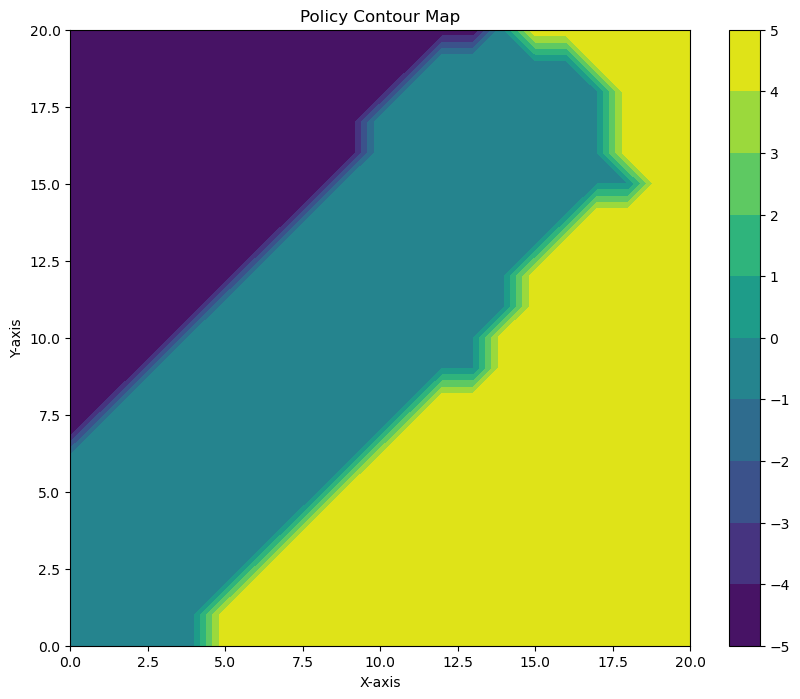

In [9]:
import matplotlib.pyplot as plt

# Assuming learner.policy is a dictionary with tuple keys
policy_dict = learner.policy

# Create an empty 2D array and fill it with the policy values
policy = np.zeros((21,21))
for (x, y), value in policy_dict.items():
    policy[x, y] = value

# Create a meshgrid for plotting
x = np.arange(policy.shape[0])
y = np.arange(policy.shape[1])
X, Y = np.meshgrid(x, y)

# Define the discrete color levels
levels = np.arange(-5, 6, 1)

# Create the contour plot with discrete color steps
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, policy.T, levels=levels, cmap='viridis')
plt.colorbar(contour, ticks=levels)
plt.title('Policy Contour Map')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [164]:

policy = {state: 0 for state in states}
value_function = {state: 0 for state in states}

state = states[0]

env = rental_problem

all_possible_next_states = product(states, map(lambda cars: cars*env.reward_per_car, range((env.max_storage_of_locations+1))))


In [165]:
prob_of_next_state = [env.p(list(state), policy[state], next_state, reward) * (reward + 0.9 * value_function[next_state]) for next_state, reward in all_possible_next_states]
display(len(prob_of_next_state))
sum(prob_of_next_state)

9261

6.830321570988144